In [1]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
import torch
from dataset import load_ohio_data
from model   import GlucoseTransformer, TransformerConfig
from trainer import Trainer, TrainingConfig

TRAIN_DIR = "OhioT1DM/2020/train/"
TEST_DIR  = "OhioT1DM/2020/test/"
DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Load data ─────────────────────────────────────────────────────────────────
split = load_ohio_data(
    train_dir   = TRAIN_DIR,
    test_dir    = TEST_DIR,
    batch_size  = 64,
    num_workers = 0,
    verbose     = False,
)

# ── Config ────────────────────────────────────────────────────────────────────
model_config = TransformerConfig()
train_config = TrainingConfig()

# ── Build model ───────────────────────────────────────────────────────────────
model = GlucoseTransformer(model_config).to(DEVICE)
print(f"Device          : {DEVICE}")
print(f"Model parameters: {model.count_parameters():,}")
print(f"Train sequences : {len(split.train_loader.dataset):,}")
print(f"Val sequences   : {len(split.val_loader.dataset):,}")

# ── Train ─────────────────────────────────────────────────────────────────────
trainer = Trainer(model, train_config, model_config)
history = trainer.fit(split.train_loader, split.val_loader)

Patient 540: 11649 valid sequences from 13110 grid timesteps (glucose mean=137.1, std=55.0)
Patient 540: 2842 valid sequences from 3067 grid timesteps (glucose mean=137.1, std=55.0)
Patient 544: 10190 valid sequences from 12672 grid timesteps (glucose mean=165.2, std=59.9)
Patient 544: 2610 valid sequences from 3137 grid timesteps (glucose mean=165.2, std=59.9)
Patient 552: 8707 valid sequences from 11098 grid timesteps (glucose mean=146.7, std=54.6)
Patient 552: 2286 valid sequences from 3951 grid timesteps (glucose mean=146.7, std=54.6)
Patient 567: 10038 valid sequences from 13537 grid timesteps (glucose mean=153.8, std=60.9)
  Patient 567: 'meal' stream absent — no carb features for this file
Patient 567: 2249 valid sequences from 2872 grid timesteps (glucose mean=153.8, std=60.9)
Patient 584: 11803 valid sequences from 13249 grid timesteps (glucose mean=192.5, std=65.4)
Patient 584: 2618 valid sequences from 2996 grid timesteps (glucose mean=192.5, std=65.4)
Patient 596: 10430 val

/Users/owenlee/miniconda3/envs/ai2026_good/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


KeyboardInterrupt: 

In [3]:
from calibrator import ConformalCalibrator
from model import GlucoseTransformer
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load best model checkpoint
checkpoint = torch.load(
    "checkpoints/best_model.pt",
    map_location = DEVICE,
    weights_only = False,
)
model_config = checkpoint['model_config']
model        = GlucoseTransformer(model_config).to(DEVICE)
model.load_state_dict(checkpoint['model_state'])
model.eval()

print(f"Loaded best model from epoch "
      f"{checkpoint['epoch'] + 1} "
      f"(val loss {checkpoint['val_loss']:.6f})")

# Run conformal calibration on validation set
calibrator = ConformalCalibrator(model, model_config, DEVICE)
results    = calibrator.calibrate(
    cal_loader    = split.val_loader,
    patient_stats = split.patient_stats,
)

# Save calibration results
calibrator.save("checkpoints/calibration.pkl")

Loaded best model from epoch 8 (val loss 0.081435)
Running conformal calibration...
  Quantiles : [0.05, 0.25, 0.5, 0.75, 0.95]
  Calibration samples: 18,848
  Calibrating intervals: ['90%', '50%']


  90% interval (q5/q95):
    Calibration samples : 18,848
    Raw coverage        : 0.9192  (target 0.90, gap +0.0192)
    Adjusted coverage   : 0.9000  (gap +0.0000)
    q_hat (normalized)  : -0.035023
    q_hat (mg/dL, mean) : -2.01
    Range-specific coverage after adjustment:
      hypo      : 0.6633  (n=496)
      normal    : 0.9109  (n=12,053)
      hyper     : 0.8979  (n=6,299)

  50% interval (q25/q75):
    Calibration samples : 18,848
    Raw coverage        : 0.5051  (target 0.50, gap +0.0051)
    Adjusted coverage   : 0.5001  (gap +0.0001)
    q_hat (normalized)  : -0.001946
    q_hat (mg/dL, mean) : -0.11
    Range-specific coverage after adjustment:
      hypo      : 0.2581  (n=496)
      normal    : 0.5103  (n=12,053)
      hyper     : 0.4994  (n=6,299)
Calibration results sa

In [5]:
import importlib
import calibrator as calibrator_module
importlib.reload(calibrator_module)

from calibrator import ConformalCalibrator
from model import GlucoseTransformer
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reload best model
checkpoint = torch.load(
    "checkpoints/best_model.pt",
    map_location = DEVICE,
    weights_only = False,
)
model_config = checkpoint['model_config']
model        = GlucoseTransformer(model_config).to(DEVICE)
model.load_state_dict(checkpoint['model_state'])
model.eval()
print(f"Loaded best model from epoch "
      f"{checkpoint['epoch'] + 1} "
      f"(val loss {checkpoint['val_loss']:.6f})")

# Recreate calibrator instance
calibrator_obj = ConformalCalibrator(model, model_config, DEVICE)

# Run global calibration first — range calibration depends on its results
results = calibrator_obj.calibrate(
    cal_loader    = split.val_loader,
    patient_stats = split.patient_stats,
)

# Now run range-specific calibration on the instance
range_results = calibrator_obj.calibrate_by_range(
    cal_loader = split.val_loader,
)

# Save
calibrator_obj.save("checkpoints/calibration.pkl")

Loaded best model from epoch 8 (val loss 0.081435)
Running conformal calibration...
  Quantiles : [0.05, 0.25, 0.5, 0.75, 0.95]


/Users/owenlee/miniconda3/envs/ai2026_good/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


  Calibration samples: 18,848
  Calibrating intervals: ['90%', '50%']


  90% interval (q5/q95):
    Calibration samples : 18,848
    Raw coverage        : 0.9192  (target 0.90, gap +0.0192)
    Adjusted coverage   : 0.9000  (gap +0.0000)
    q_hat (normalized)  : -0.035023
    q_hat (mg/dL, mean) : -2.01
    Range-specific coverage after adjustment:
      hypo      : 0.6633  (n=496)
      normal    : 0.9109  (n=12,053)
      hyper     : 0.8979  (n=6,299)

  50% interval (q25/q75):
    Calibration samples : 18,848
    Raw coverage        : 0.5051  (target 0.50, gap +0.0051)
    Adjusted coverage   : 0.5001  (gap +0.0001)
    q_hat (normalized)  : -0.001946
    q_hat (mg/dL, mean) : -0.11
    Range-specific coverage after adjustment:
      hypo      : 0.2581  (n=496)
      normal    : 0.5103  (n=12,053)
      hyper     : 0.4994  (n=6,299)

Running range-specific conformal calibration...
  hypo      : 496 samples (2.6%)
  normal    : 12,053 samples (63.9%)
  hyper     : 6,299 samples (33

In [5]:
import importlib

# Reload all modules to pick up latest file changes
import calibrator as calibrator_module
import evaluator  as evaluator_module
importlib.reload(calibrator_module)
importlib.reload(evaluator_module)

from calibrator import ConformalCalibrator
from evaluator  import Evaluator
from model      import GlucoseTransformer
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Reload best model ─────────────────────────────────────────────────────────
checkpoint = torch.load(
    "checkpoints/best_model.pt",
    map_location = DEVICE,
    weights_only = False,
)
model_config = checkpoint['model_config']
model        = GlucoseTransformer(model_config).to(DEVICE)
model.load_state_dict(checkpoint['model_state'])
model.eval()
print(f"Loaded best model from epoch "
      f"{checkpoint['epoch'] + 1} "
      f"(val loss {checkpoint['val_loss']:.6f})")

# ── Rebuild calibrator instance ───────────────────────────────────────────────
calibrator_instance = ConformalCalibrator(model, model_config, DEVICE)

# Global calibration must run first
calibrator_instance.calibrate(
    cal_loader    = split.val_loader,
    patient_stats = split.patient_stats,
)

# Range-specific calibration
calibrator_instance.calibrate_by_range(
    cal_loader = split.val_loader,
)

calibrator_instance.save("checkpoints/calibration.pkl")

Loaded best model from epoch 8 (val loss 0.081435)
Running conformal calibration...
  Quantiles : [0.05, 0.25, 0.5, 0.75, 0.95]
  Calibration samples: 18,848
  Calibrating intervals: ['90%', '50%']


  90% interval (q5/q95):
    Calibration samples : 18,848
    Raw coverage        : 0.9192  (target 0.90, gap +0.0192)
    Adjusted coverage   : 0.9000  (gap +0.0000)
    q_hat (normalized)  : -0.035023
    q_hat (mg/dL, mean) : -2.01
    Range-specific coverage after adjustment:
      hypo      : 0.6633  (n=496)
      normal    : 0.9109  (n=12,053)
      hyper     : 0.8979  (n=6,299)

  50% interval (q25/q75):
    Calibration samples : 18,848
    Raw coverage        : 0.5051  (target 0.50, gap +0.0051)
    Adjusted coverage   : 0.5001  (gap +0.0001)
    q_hat (normalized)  : -0.001946
    q_hat (mg/dL, mean) : -0.11
    Range-specific coverage after adjustment:
      hypo      : 0.2581  (n=496)
      normal    : 0.5103  (n=12,053)
      hyper     : 0.4994  (n=6,299)

Running range-specifi

In [6]:
# Note: pass calibrator_instance (the object), not the module
evaluator_instance = Evaluator(model, calibrator_instance, model_config, DEVICE)
results_df = evaluator_instance.evaluate(
    test_loaders  = split.test_loaders,
    patient_stats = split.patient_stats,
)

results_df.to_csv("checkpoints/results.csv")
print("\nResults saved to checkpoints/results.csv")

Evaluating on test set...

── Patient 540 (n=2,842) ─────────────────────────────
  Point:   RMSE=22.08  MAE=16.11  MBE=-4.18 mg/dL
  CEG:     A=84.9%  A+B=100.0%
  Global conformal:
    90%: cov=0.8702  width=61.7 mg/dL
    50%: cov=0.4778  width=23.4 mg/dL
  Range-specific conformal:
    90%: cov=0.8681  width=61.8 mg/dL
    50%: cov=0.4789  width=24.0 mg/dL
    hypo    : n= 130  RMSE=15.33  cov=0.8308  width=56.9
    normal  : n=1793  RMSE=18.98  cov=0.8879  width=58.7
    hyper   : n= 919  RMSE=27.77  cov=0.8346  width=68.6

── Patient 544 (n=2,610) ─────────────────────────────
  Point:   RMSE=16.82  MAE=12.16  MBE=+0.30 mg/dL
  CEG:     A=92.9%  A+B=100.0%
  Global conformal:
    90%: cov=0.9372  width=61.3 mg/dL
    50%: cov=0.5594  width=22.5 mg/dL
  Range-specific conformal:
    90%: cov=0.9310  width=60.5 mg/dL
    50%: cov=0.5609  width=22.5 mg/dL
    hypo    : n=  31  RMSE=16.14  cov=0.9032  width=63.2
    normal  : n=1759  RMSE=13.90  cov=0.9267  width=53.3
    hyper   : n

In [9]:
hypo_cal_samples = {
    '540': 178, '544': 29, '552': 73,
    '567': 127, '584': 46, '596': 43
}
hypo_test_coverage = {
    '540': 0.8308, '544': 0.9032, '552': 0.6875,
    '567': 0.9570, '584': 0.3077, '596': 0.3621
}

import numpy as np
n_cal = np.array([hypo_cal_samples[p]    for p in sorted(hypo_cal_samples)])
n_cov = np.array([hypo_test_coverage[p]  for p in sorted(hypo_test_coverage)])
corr  = np.corrcoef(n_cal, n_cov)[0, 1]
print(f"Pearson correlation between hypo calibration n "
      f"and test coverage: {corr:.4f}")

Pearson correlation between hypo calibration n and test coverage: 0.5035


In [10]:
hypo_frequency = {
    '540': 5.1, '544': 0.9, '552': 2.8,
    '567': 4.2, '584': 1.3, '596': 1.4
}
hypo_test_coverage = {
    '540': 0.8308, '544': 0.9032, '552': 0.6875,
    '567': 0.9570, '584': 0.3077, '596': 0.3621
}

freq = np.array([hypo_frequency[p]     for p in sorted(hypo_frequency)])
cov  = np.array([hypo_test_coverage[p] for p in sorted(hypo_test_coverage)])
corr_freq = np.corrcoef(freq, cov)[0, 1]
print(f"Pearson correlation between hypo frequency (%) "
      f"and test coverage: {corr_freq:.4f}")

Pearson correlation between hypo frequency (%) and test coverage: 0.5441


In [11]:
hypo_rmse = {
    '540': 15.33, '544': 16.14, '552': 17.21,
    '567': 12.39, '584': 43.65, '596': 25.66
}
hypo_test_coverage = {
    '540': 0.8308, '544': 0.9032, '552': 0.6875,
    '567': 0.9570, '584': 0.3077, '596': 0.3621
}

rmse = np.array([hypo_rmse[p]         for p in sorted(hypo_rmse)])
cov  = np.array([hypo_test_coverage[p] for p in sorted(hypo_test_coverage)])
corr_rmse = np.corrcoef(rmse, cov)[0, 1]
print(f"Pearson correlation between hypo RMSE "
      f"and test coverage: {corr_rmse:.4f}")

Pearson correlation between hypo RMSE and test coverage: -0.8787


/Users/owenlee/miniconda3/envs/ai2026_good/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Saved: figures/fig1_prediction_intervals.png


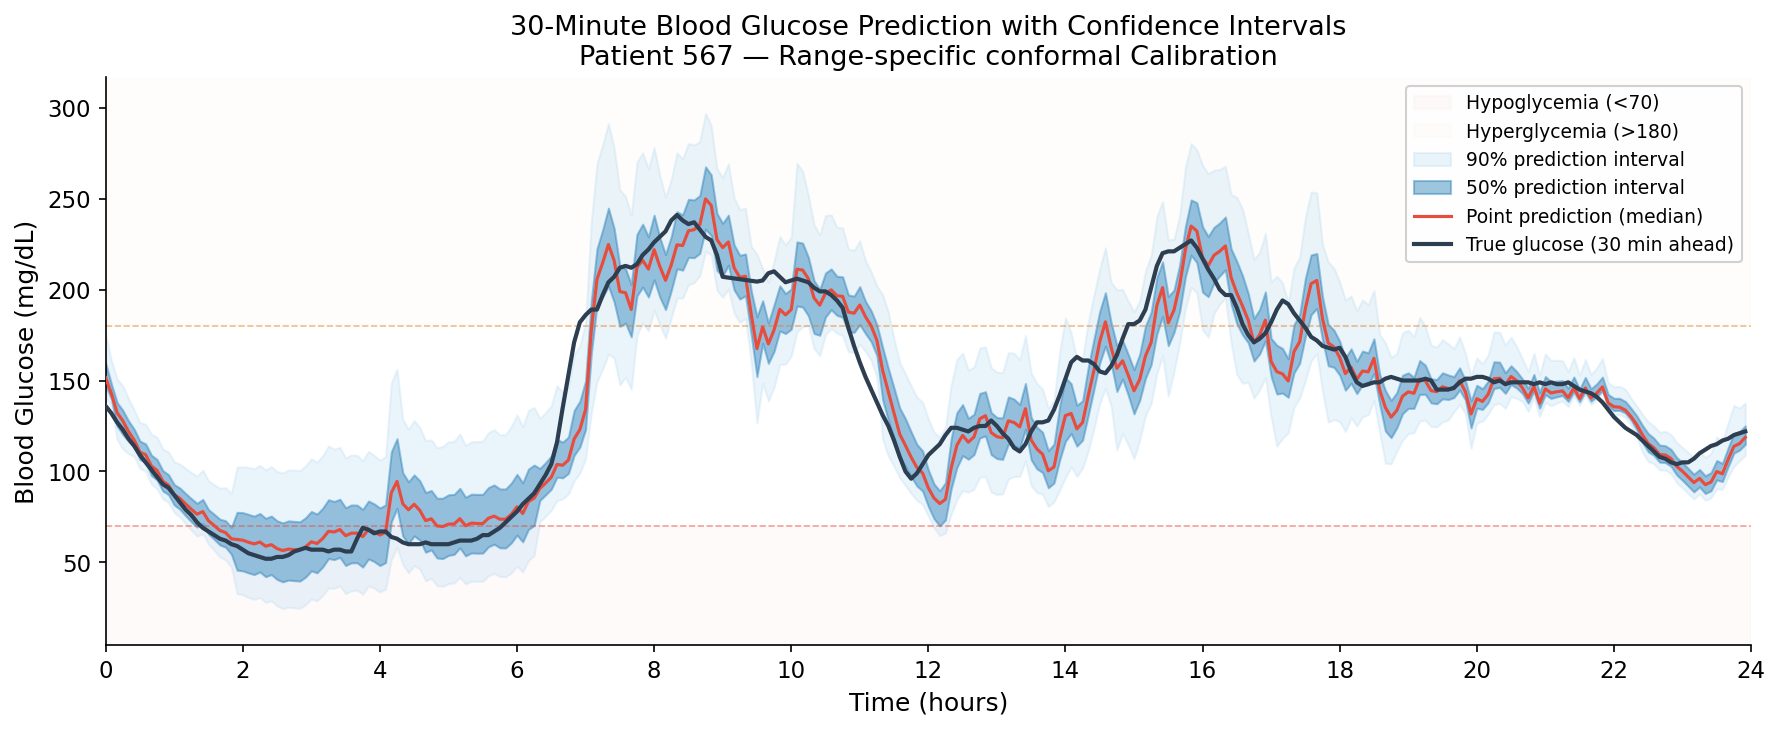

Saved: figures/fig2_coverage_comparison.png


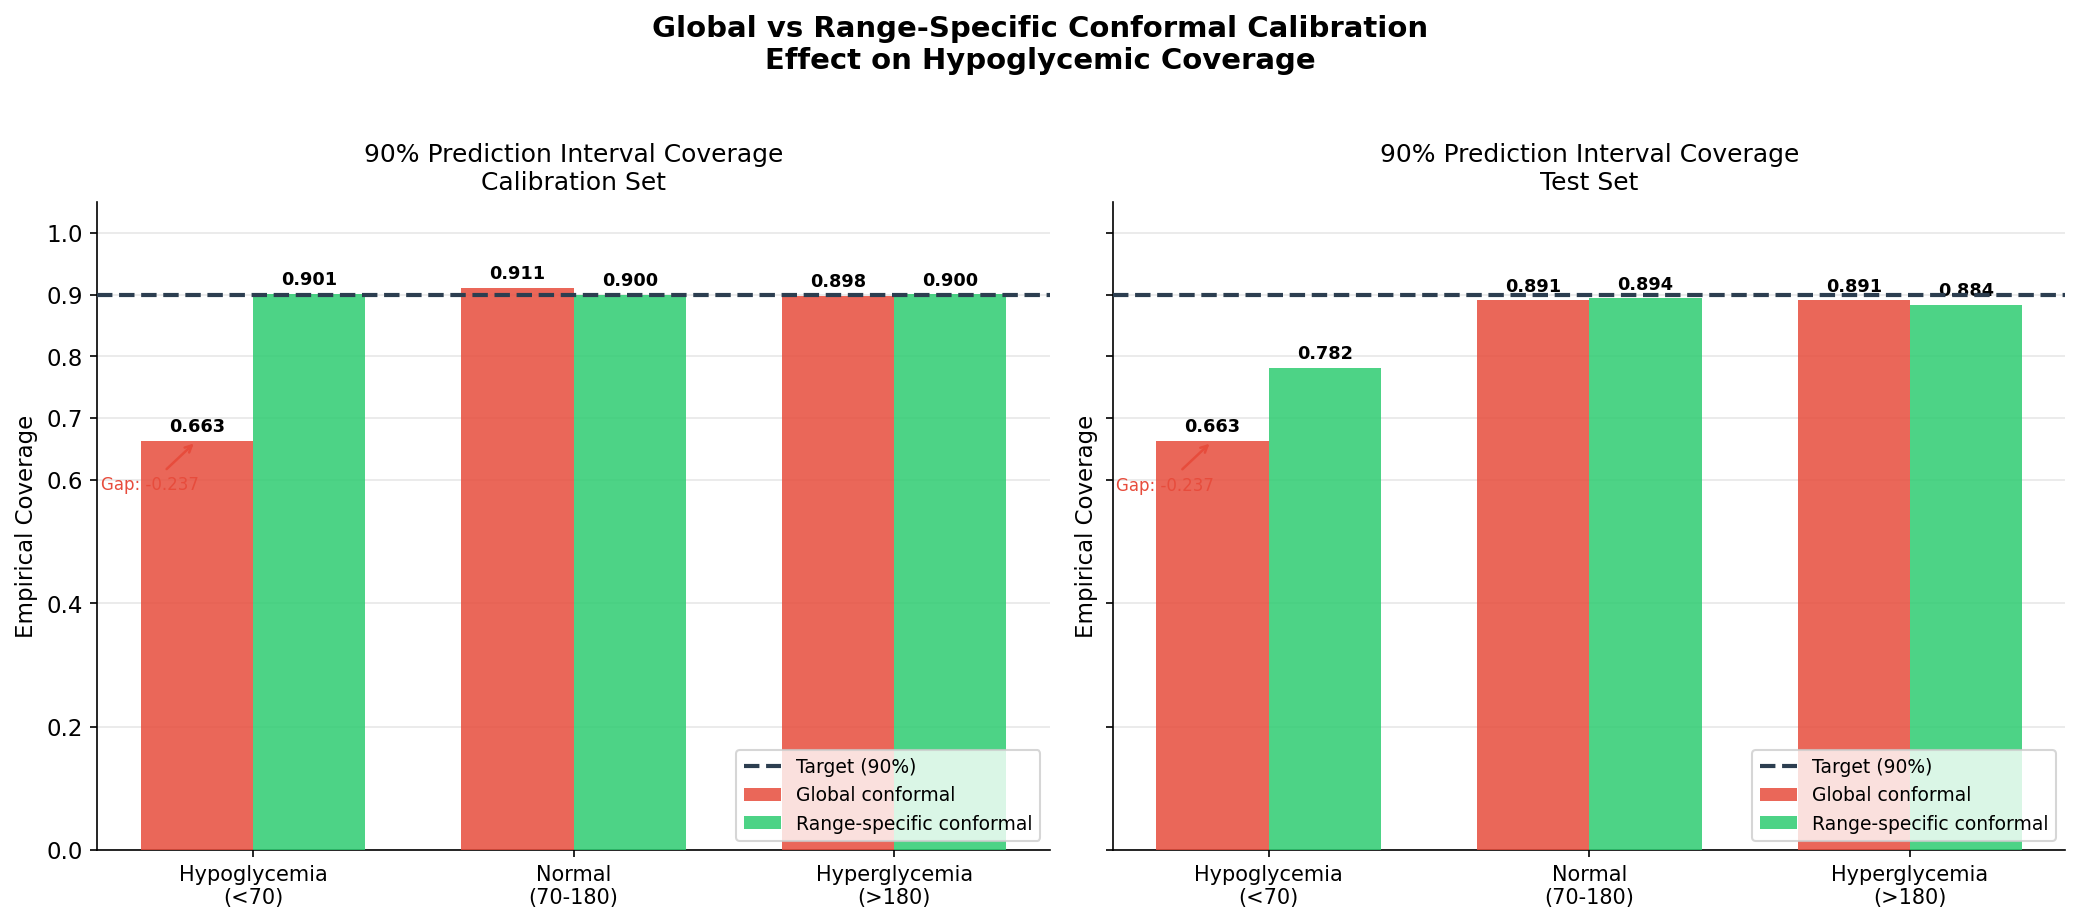

Saved: figures/fig3_rmse_coverage_scatter.png


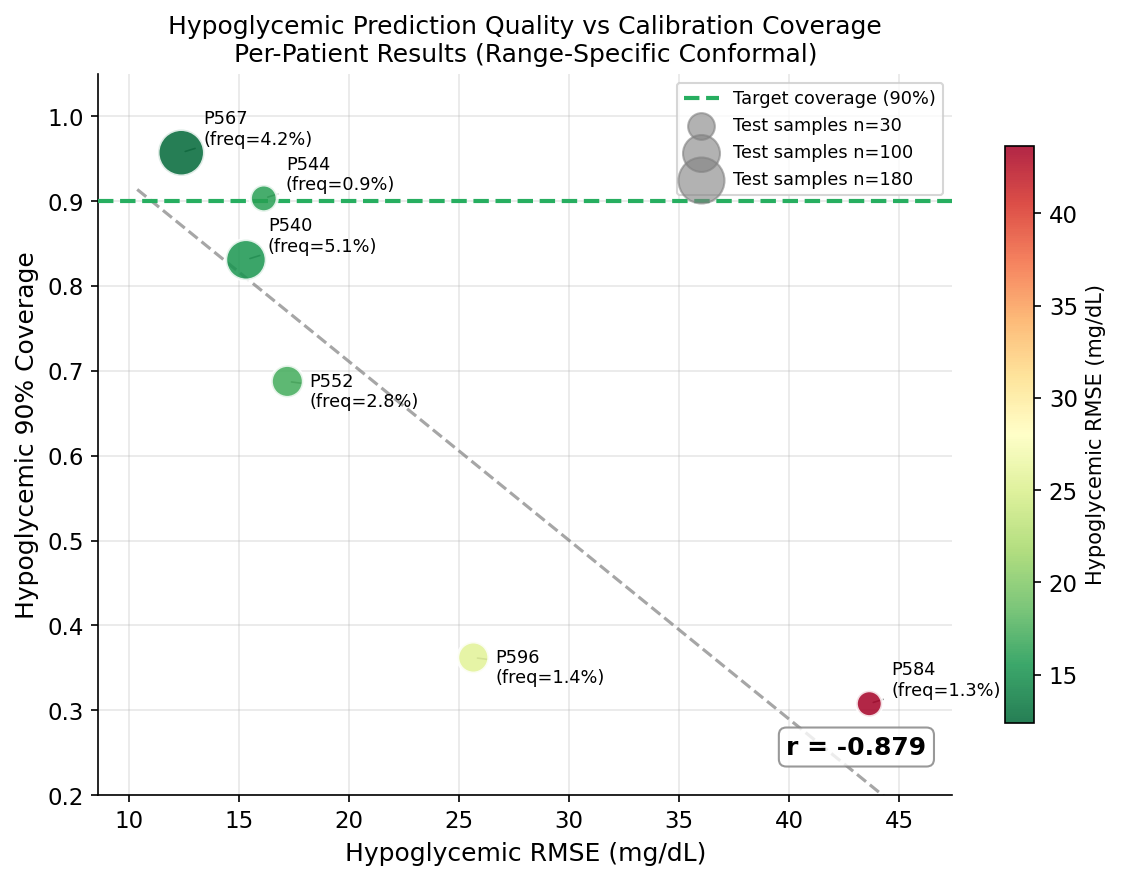

/Users/owenlee/miniconda3/envs/ai2026_good/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Saved: figures/fig4_clarke_error_grid.png


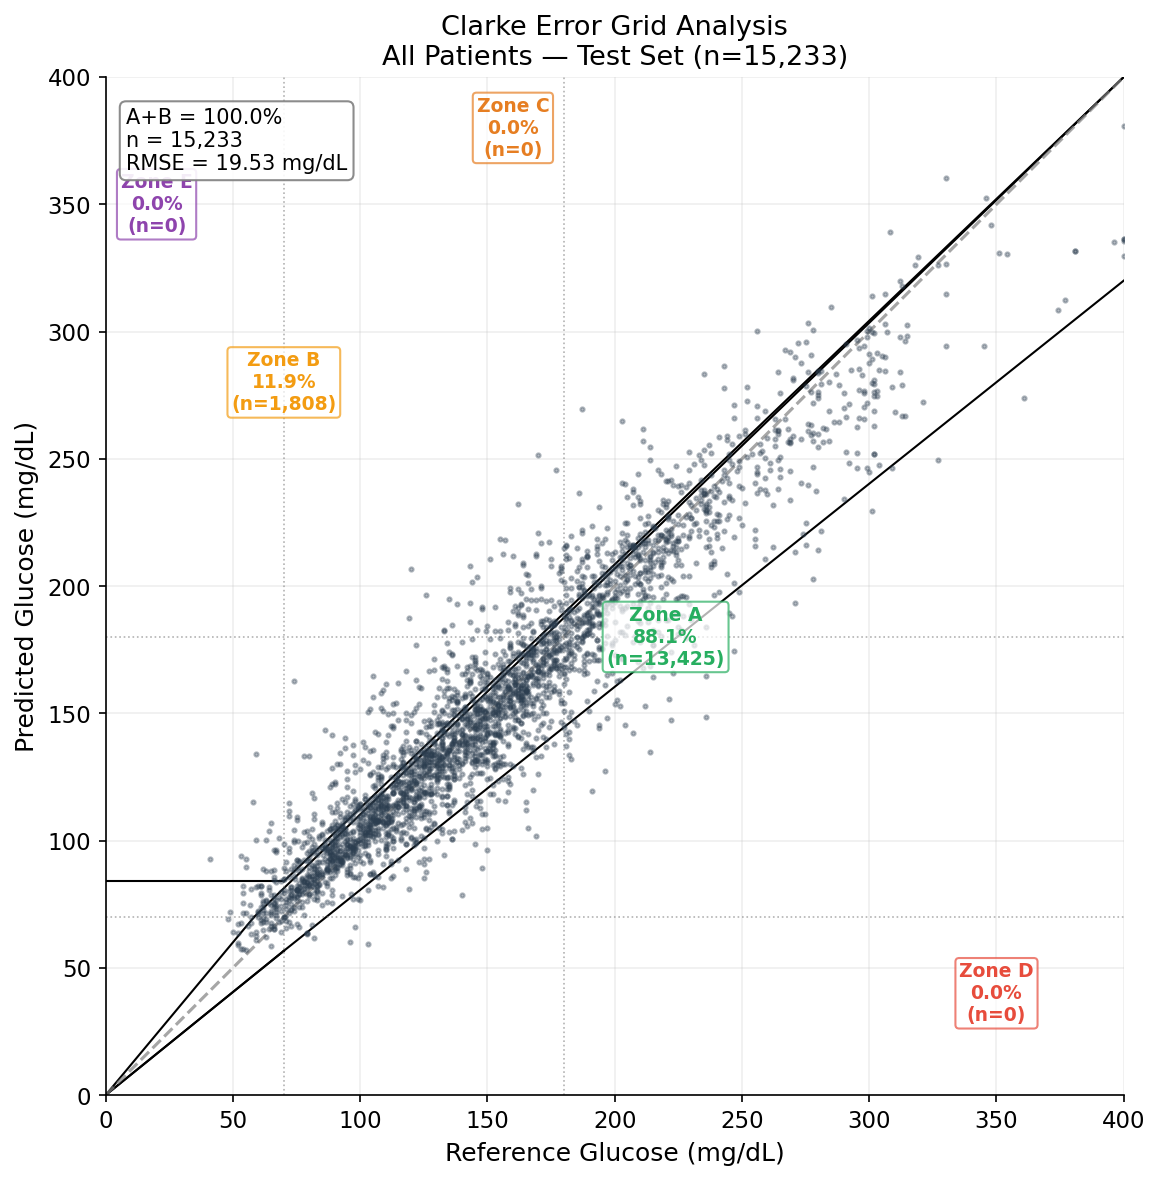

In [7]:
from visualize import (
    collect_predictions_for_plot,
    plot_prediction_intervals,
    plot_coverage_comparison,
    plot_rmse_coverage_scatter,
    plot_clarke_error_grid,
)
import numpy as np

# ── Figure 1: Prediction intervals for patient 567
# (best calibrated patient — most illustrative)
plot_data_567 = collect_predictions_for_plot(
    model          = model,
    calibrator_obj = calibrator_instance,
    loader         = split.test_loaders['567'],
    patient_id     = '567',
    patient_stats  = split.patient_stats,
    device         = DEVICE,
    n_samples      = 288,
)
plot_prediction_intervals(
    data       = plot_data_567,
    patient_id = '567',
    start_h    = 0,
    n_hours    = 24,
    use_range  = True,
)

# ── Figure 2: Coverage comparison
plot_coverage_comparison(results_df)

# ── Figure 3: RMSE vs coverage scatter
plot_rmse_coverage_scatter()

# ── Figure 4: Clarke Error Grid
# Collect all test predictions
all_preds_list   = []
all_targets_list = []

model.eval()
with torch.no_grad():
    for pid, loader in split.test_loaders.items():
        stats = split.patient_stats[pid]
        mu, sigma = stats.glucose_mean, stats.glucose_std
        for batch in loader:
            features = batch['features'].to(DEVICE)
            mask     = batch['attention_mask'].to(DEVICE)
            preds    = model(features, mask).cpu().numpy()
            preds    = np.sort(preds, axis=1)
            median_idx = calibrator_instance.quantiles.index(0.50)
            pred_mgdl  = preds[:, median_idx] * sigma + mu
            all_preds_list.append(pred_mgdl)
            all_targets_list.append(batch['target_raw'].numpy().flatten())

all_preds_plot   = np.concatenate(all_preds_list)
all_targets_plot = np.concatenate(all_targets_list)

plot_clarke_error_grid(all_targets_plot, all_preds_plot)

In [16]:
# Does hypoglycemic training data scarcity predict hypo RMSE?

hypo_train_freq = {
    # From the training XML analysis we did earlier
    # These are the calibration set frequencies as a proxy
    '540': 5.1,   # % of readings hypoglycemic
    '544': 0.9,
    '552': 2.8,
    '567': 4.2,
    '584': 1.3,
    '596': 1.4,
}
hypo_rmse = {
    '540': 15.33,
    '544': 16.14,
    '552': 17.21,
    '567': 12.39,
    '584': 43.65,
    '596': 25.66,
}

patients = sorted(hypo_train_freq.keys())
freq = np.array([hypo_train_freq[p] for p in patients])
rmse = np.array([hypo_rmse[p]       for p in patients])

corr = np.corrcoef(freq, rmse)[0, 1]
print(f"Correlation between hypo training frequency "
      f"and hypo RMSE: {corr:.4f}")

# Print the full picture
print(f"\n{'Patient':>10}  {'Hypo Freq':>10}  {'Hypo RMSE':>10}")
for p in patients:
    print(f"{p:>10}  {hypo_train_freq[p]:>10.1f}  {hypo_rmse[p]:>10.2f}")

Correlation between hypo training frequency and hypo RMSE: -0.5542

   Patient   Hypo Freq   Hypo RMSE
       540         5.1       15.33
       544         0.9       16.14
       552         2.8       17.21
       567         4.2       12.39
       584         1.3       43.65
       596         1.4       25.66
